# SVM (support vector machine)
- make a boundary between data to split in twi parts
- lower half is support vaector
- draw a imaginary boundary to protect main boundary
- margin=distance btewwn main boundary and imaginary boundary
- to take a parmeter margin increses that parmeter is kernal
- inside kernal=c-striction measure in margin
- gamma=striction in margin (data point how  much infulenced in a machine)
- svc(support vector classifier)

# Heart Disease Prediction using SVM

In [28]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [29]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import pickle


In [30]:

df = pd.read_csv("Heart_Disease_Prediction (1).csv")

In [31]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [32]:
df.tail()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7,Absence
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7,Absence
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3,Absence
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6,Absence
269,67,1,4,160,286,0,2,108,1,1.5,2,3,3,Presence


In [33]:
df.shape

(270, 14)

In [34]:
print("Rows : ",df.shape[0])
print("Columns : ",df.shape[1])

Rows :  270
Columns :  14


In [35]:
df.columns


Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease'],
      dtype='object')

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [37]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


In [38]:
df.isnull().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [39]:
df.duplicated().sum()

np.int64(0)

In [40]:
df.drop_duplicates(inplace=True)

In [41]:
df.shape

(270, 14)

In [42]:
df['Heart Disease'].value_counts()

Heart Disease
Absence     150
Presence    120
Name: count, dtype: int64

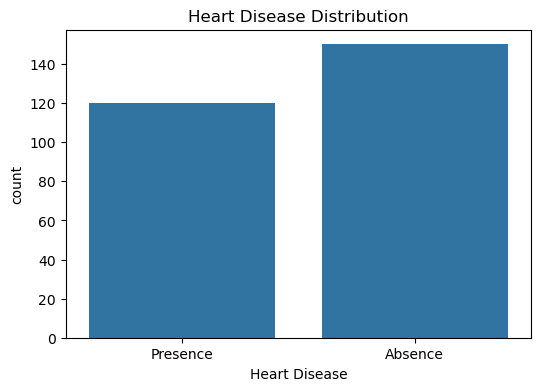

In [43]:
plt.figure(figsize=(6,4))

sns.countplot(x='Heart Disease',data=df)

plt.title("Heart Disease Distribution")

plt.show()

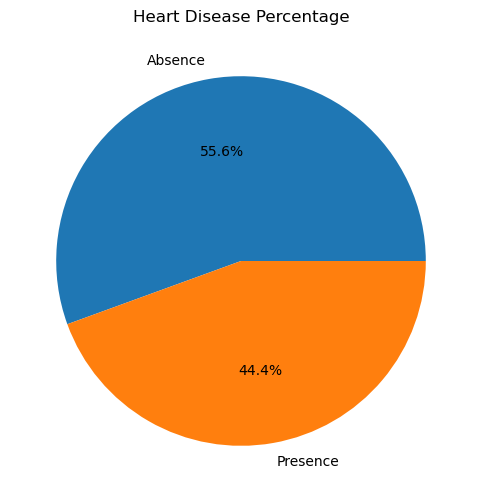

In [44]:
plt.figure(figsize=(6,6))

df['Heart Disease'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")

plt.title("Heart Disease Percentage")

plt.show()

In [45]:
df.dtypes

Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
Heart Disease               object
dtype: object

In [46]:
for col in df.columns:
    print("="*50)
    print(col)
    print(df[col].unique())

Age
[70 67 57 64 74 65 56 59 60 63 53 44 61 71 46 40 48 43 47 54 51 58 66 37
 50 42 62 49 52 45 41 76 39 35 55 34 38 69 68 77 29]
Sex
[1 0]
Chest pain type
[4 3 2 1]
BP
[130 115 124 128 120 110 140 150 135 142 134 112 132 138 160 170 144 122
 152 101 126 118 136 105 174 145 108 156 106 104  94 146 148 178 125 100
 165 180 158 200 117 192 123 129 102 155 172]
Cholesterol
[322 564 261 263 269 177 256 239 293 407 234 226 235 303 149 311 203 211
 199 229 245 204 288 275 243 295 230 265 228 215 326 200 207 273 180 222
 223 209 233 197 218 246 225 315 205 417 195 198 166 178 249 281 126 305
 240 276 319 242 260 354 309 208 236 270 214 201 244 306 221 330 266 206
 212 302 313 141 237 289 254 274 258 160 327 304 271 283 188 286 360 267
 196 232 277 210 213 282 167 224 268 250 219 217 308 193 231 262 259 325
 299 182 294 298 409 172 184 394 174 255 248 300 318 216 252 227 220 168
 183 341 186 307 164 257 321 264 253 185 290 175 353 335 247 340 284 192]
FBS over 120
[0 1]
EKG results
[2 0 1]
Max

In [47]:
categorical_columns = df.select_dtypes(include=['object']).columns

categorical_columns

Index(['Heart Disease'], dtype='object')

In [48]:
le = LabelEncoder()

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

In [49]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


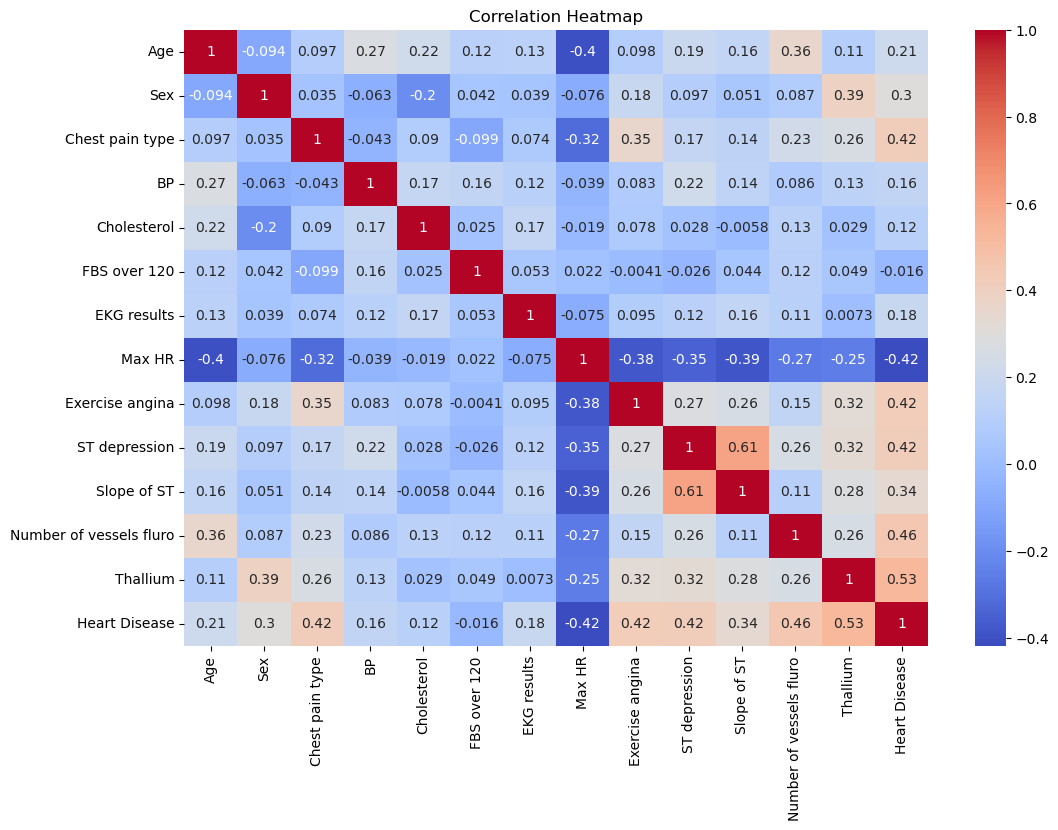

In [50]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

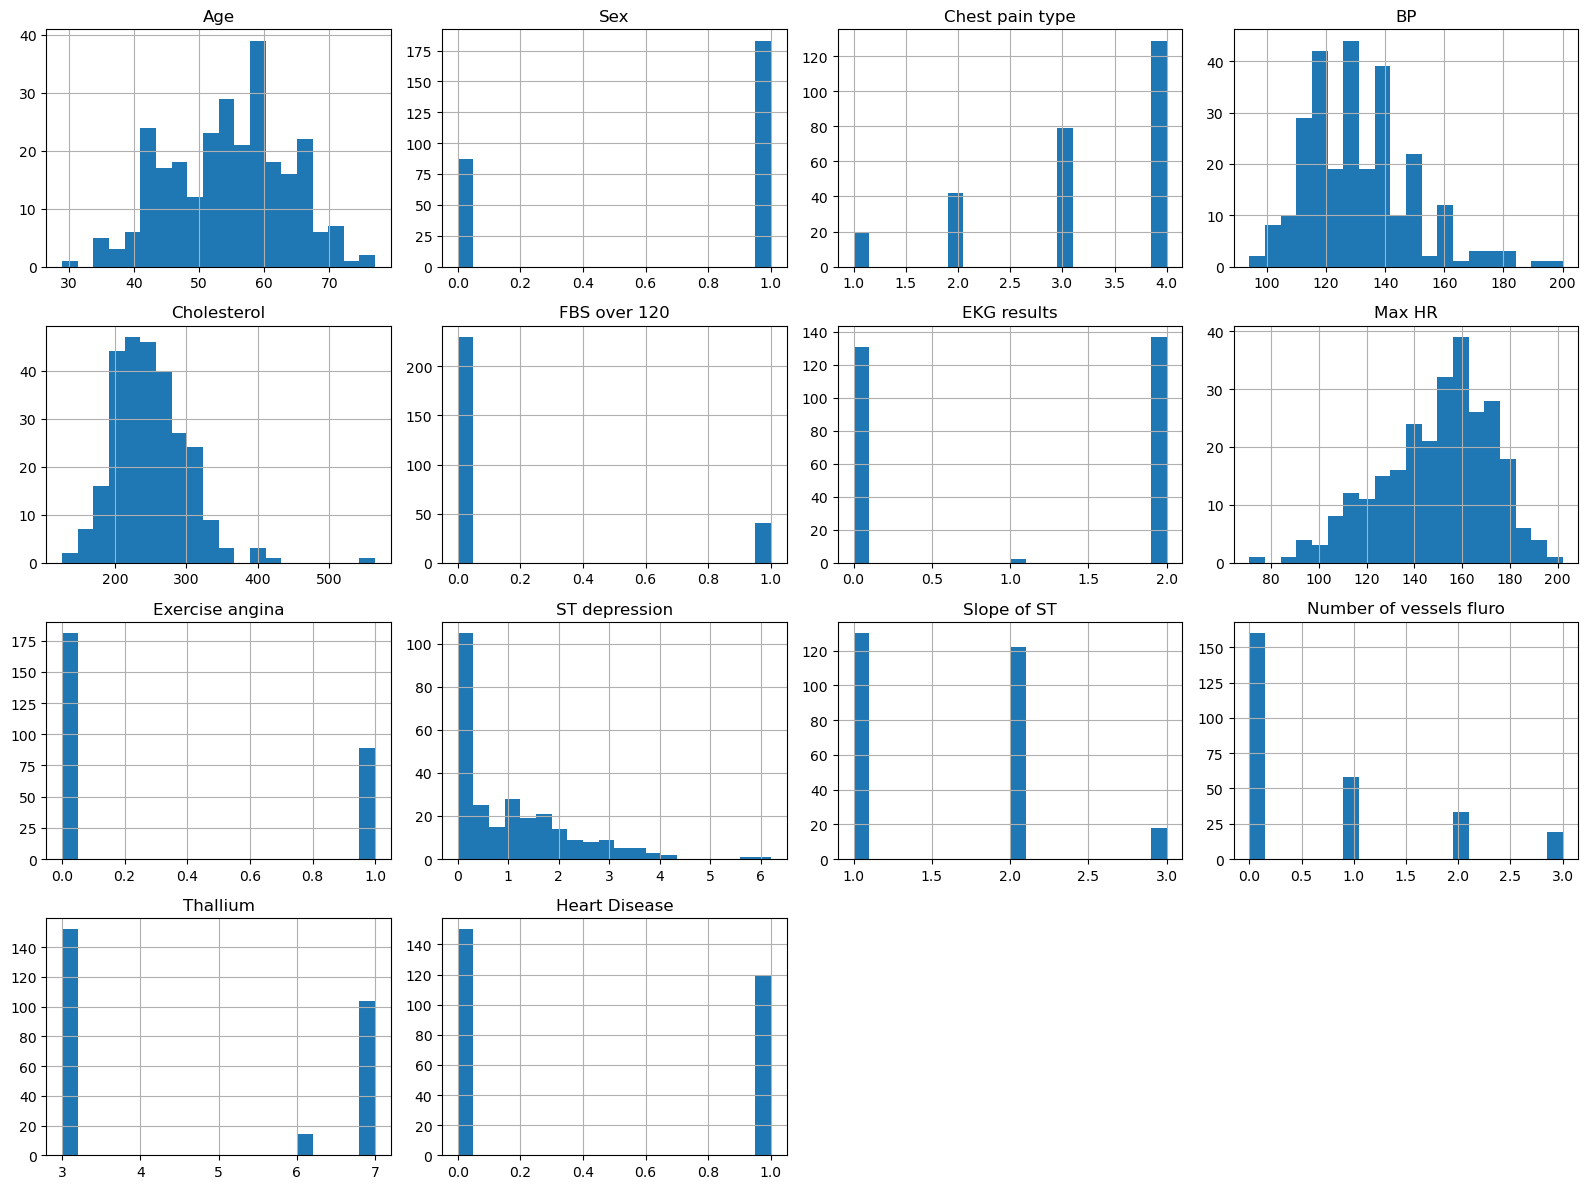

In [51]:
df.hist(
    figsize=(16,12),
    bins=20
)

plt.tight_layout()

plt.show()

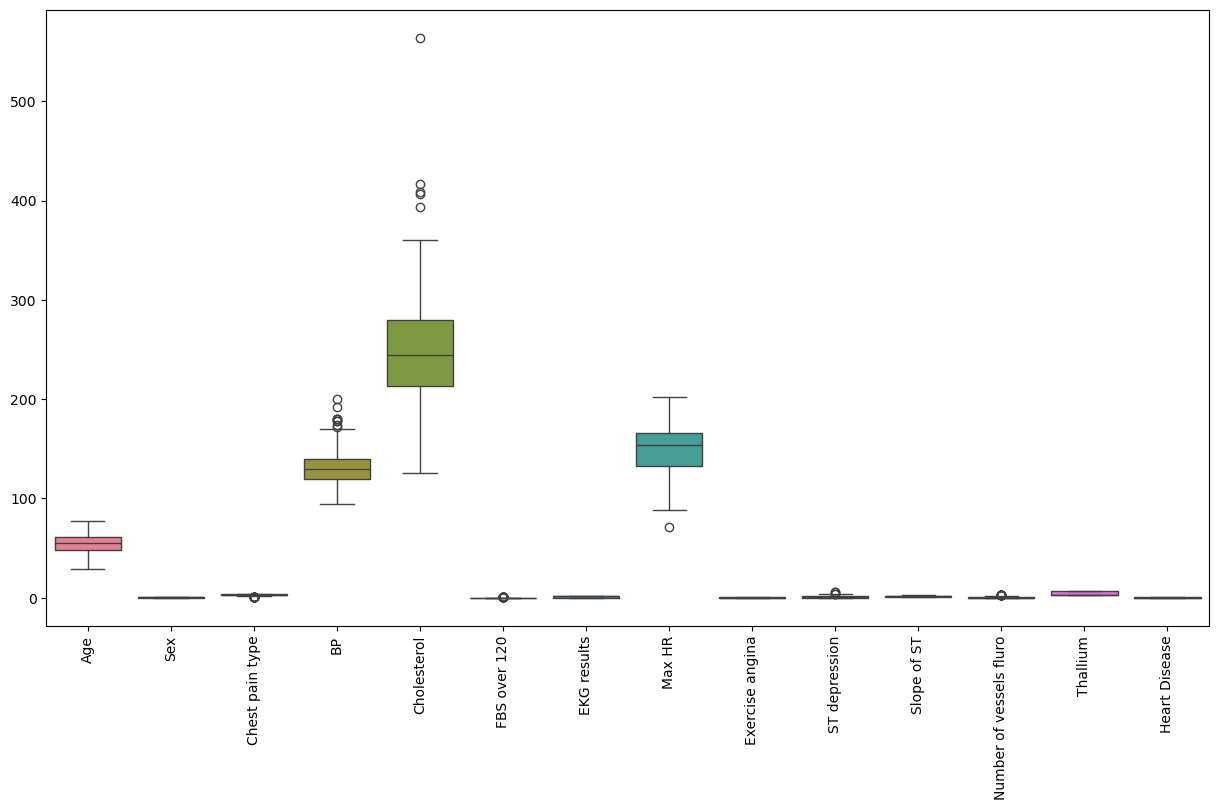

In [52]:
plt.figure(figsize=(15,8))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.show()

In [53]:
correlation = df.corr()['Heart Disease'].sort_values(ascending=False)

print(correlation)

Heart Disease              1.000000
Thallium                   0.525020
Number of vessels fluro    0.455336
Exercise angina            0.419303
ST depression              0.417967
Chest pain type            0.417436
Slope of ST                0.337616
Sex                        0.297721
Age                        0.212322
EKG results                0.182091
BP                         0.155383
Cholesterol                0.118021
FBS over 120              -0.016319
Max HR                    -0.418514
Name: Heart Disease, dtype: float64


In [54]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    int64  
dtypes: float64(1), int64(13)
m

In [56]:
df.shape

(270, 14)

In [57]:
X = df.drop("Heart Disease", axis=1)

y = df["Heart Disease"]

In [58]:
X.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3


In [59]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: Heart Disease, dtype: int64

In [60]:
print("X Shape :", X.shape)
print("y Shape :", y.shape)

X Shape : (270, 13)
y Shape : (270,)


In [61]:
X.columns

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium'],
      dtype='object')

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [63]:
print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print()

print("Training Target :", y_train.shape)
print("Testing Target :", y_test.shape)

Training Features : (216, 13)
Testing Features : (54, 13)

Training Target : (216,)
Testing Target : (54,)


In [64]:
print("Training Data")

print(y_train.value_counts())

print()

print("Testing Data")

print(y_test.value_counts())

Training Data
Heart Disease
0    120
1     96
Name: count, dtype: int64

Testing Data
Heart Disease
0    30
1    24
Name: count, dtype: int64


In [65]:
scaler = StandardScaler()

In [66]:
X_train = scaler.fit_transform(X_train)

In [67]:
X_test = scaler.transform(X_test)

In [68]:
X_train

array([[-1.3361797 , -1.47528661, -0.10435568, ...,  0.69812296,
        -0.70900762, -0.85615942],
       [-0.03903446,  0.67783439,  0.9202274 , ...,  0.69812296,
         1.43288953, -0.85615942],
       [-0.36332077, -1.47528661, -0.10435568, ..., -0.95896011,
        -0.70900762, -0.85615942],
       ...,
       [-1.44427514,  0.67783439, -1.12893877, ...,  0.69812296,
        -0.70900762,  0.69787785],
       [-0.25522534,  0.67783439, -1.12893877, ..., -0.95896011,
         0.36194095, -0.85615942],
       [ 0.93382446, -1.47528661,  0.9202274 , ...,  0.69812296,
         1.43288953, -0.85615942]], shape=(216, 13))

In [69]:
np.mean(X_train)

np.float64(2.3722714201392233e-17)

In [70]:
np.std(X_train)

np.float64(1.0)

In [71]:
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("Scaler Saved Successfully")

Scaler Saved Successfully


In [72]:
model = SVC()

In [73]:
model

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [74]:
model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
)

In [75]:
model.get_params()

{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': True,
 'random_state': 42,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [76]:

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [77]:
model

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [78]:
y_pred = model.predict(X_test)

In [79]:
print(y_pred)

[0 0 0 1 0 0 0 1 0 1 0 0 0 1 1 1 0 1 0 1 0 1 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1
 0 1 0 1 0 1 1 1 0 1 1 1 0 1 1 0 1]


In [80]:
comparison = pd.DataFrame({

    "Actual": y_test,
    "Predicted": y_pred

})

comparison.head(15)

,Actual,Predicted
195,0,0
132,0,0
162,0,0
129,1,1
66,0,0
254,0,0
38,0,0
65,1,1
97,1,0
61,1,1


In [81]:
probability = model.predict_proba(X_test)

probability[:5]

array([[0.94401993, 0.05598007],
       [0.90362387, 0.09637613],
       [0.94058016, 0.05941984],
       [0.08089977, 0.91910023],
       [0.73311292, 0.26688708]])

In [82]:
confidence = np.max(probability, axis=1)

confidence[:10]

array([0.94401993, 0.90362387, 0.94058016, 0.91910023, 0.73311292,
       0.88412897, 0.93463868, 0.97201868, 0.51149812, 0.87856045])

In [83]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", round(accuracy*100,2),"%")

Accuracy : 81.48 %


In [84]:
precision = precision_score(y_test, y_pred)

print("Precision :", round(precision*100,2),"%")

Precision : 76.92 %


In [85]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.80      0.83        30
           1       0.77      0.83      0.80        24

    accuracy                           0.81        54
   macro avg       0.81      0.82      0.81        54
weighted avg       0.82      0.81      0.82        54



In [86]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[24,  6],
       [ 4, 20]])

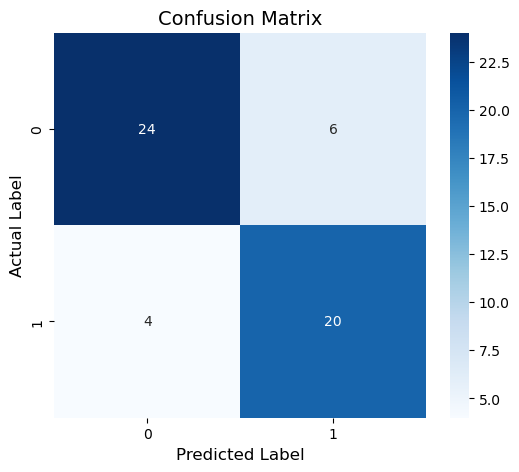

In [87]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Label", fontsize=12)

plt.ylabel("Actual Label", fontsize=12)

plt.title("Confusion Matrix", fontsize=14)

plt.show()

In [89]:
sample = np.array([[

63,
1,
1,
145,
233,
1,
2,
150,
0,
2.3,
3,
0,
6

]])

In [90]:
sample = scaler.transform(sample)

In [91]:
prediction = model.predict(sample)

print(prediction)

[0]


In [92]:
if prediction[0] == 1:

    print("Heart Disease Detected")

else:

    print("No Heart Disease")

No Heart Disease


In [93]:
with open("model.pkl","wb") as file:

    pickle.dump(model,file)

print("Model Saved Successfully")

Model Saved Successfully


In [94]:
loaded_model = pickle.load(open("model.pkl","rb"))

loaded_model

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [95]:
prediction = loaded_model.predict(sample)

prediction

array([0])

In [96]:
artifacts = {

    "model": model,

    "scaler": scaler

}

with open("artifacts.pkl","wb") as file:

    pickle.dump(artifacts,file)

print("Artifacts Saved Successfully")

Artifacts Saved Successfully


In [97]:
artifacts = pickle.load(open("artifacts.pkl","rb"))

model = artifacts["model"]

scaler = artifacts["scaler"]